install ultralytics coming with the latest YOLO version

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.0 MB/s eta 0:00:00


In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

class VisualOdometry:
    def __init__(self, camera_matrix, file_path_poses):
        """
        Initialise le système avec la matrice intrinsèque de la caméra
        et le fichier contenant les vraies positions (Ground Truth).
        """
        self.K = camera_matrix
        self.focal = self.K[0, 0]
        self.pp = (self.K[0, 2], self.K[1, 2])

        with open(file_path_poses) as f:
            self.true_poses = f.readlines()

        self.detector = cv2.FastFeatureDetector_create(threshold=25, nonmaxSuppression=True)

        self.lk_params = dict(winSize=(21, 21),
                              criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))

        self.frame_stage = 0 # 0: Initialisation, 1: Processus continu
        self.new_frame = None
        self.last_frame = None
        self.px_ref = None # Points de l'image précédente
        self.px_cur = None # Points de l'image courante

        self.cur_R = np.eye(3)
        self.cur_t = np.zeros((3, 1))

        self.traj_x, self.traj_z = [], []

    def get_absolute_scale(self, frame_id):
        """
        Calcule la distance réelle parcourue entre la frame précédente et l'actuelle
        en lisant les données de la vérité terrain (Dataset KITTI).
        """
        ss = self.true_poses[frame_id-1].strip().split()
        x_prev, y_prev, z_prev = float(ss[3]), float(ss[7]), float(ss[11])

        ss = self.true_poses[frame_id].strip().split()
        x, y, z = float(ss[3]), float(ss[7]), float(ss[11])

        scale = np.sqrt((x - x_prev)**2 + (y - y_prev)**2 + (z - z_prev)**2)
        return scale

    def process_first_frame(self):
        """Initialise les premiers points à suivre."""
        self.px_ref = self.detector.detect(self.new_frame)
        self.px_ref = np.array([x.pt for x in self.px_ref], dtype=np.float32)
        self.frame_stage = 1

    def process_frame(self, frame_id):
        """Le cœur du moteur d'odométrie."""
        if self.frame_stage == 0:
            self.process_first_frame()
            self.traj_x.append(self.cur_t[0, 0])
            self.traj_z.append(self.cur_t[2, 0])
            return

        self.px_cur, st, err = cv2.calcOpticalFlowPyrLK(self.last_frame, self.new_frame, self.px_ref, None, **self.lk_params)

        good_old = self.px_ref[st == 1]
        good_new = self.px_cur[st == 1]

        E, _ = cv2.findEssentialMat(good_new, good_old, focal=self.focal, pp=self.pp, method=cv2.RANSAC, prob=0.999, threshold=1.0)

        _, R, t, mask = cv2.recoverPose(E, good_new, good_old, focal=self.focal, pp=self.pp)

        absolute_scale = self.get_absolute_scale(frame_id)
        if absolute_scale > 0.1: # On ignore les micro-mouvements (bruit)
            self.cur_t = self.cur_t + absolute_scale * self.cur_R.dot(t)
            self.cur_R = R.dot(self.cur_R)

        self.traj_x.append(self.cur_t[0, 0])
        self.traj_z.append(self.cur_t[2, 0])

        if good_old.shape[0] < 1500:
            new_keypoints = self.detector.detect(self.new_frame)
            self.px_cur = np.array([x.pt for x in new_keypoints], dtype=np.float32)

        self.px_ref = self.px_cur

Chargement de l'IA YOLOv8...

0: 384x640 2 cars, 12.6ms
Speed: 2.8ms preprocess, 12.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


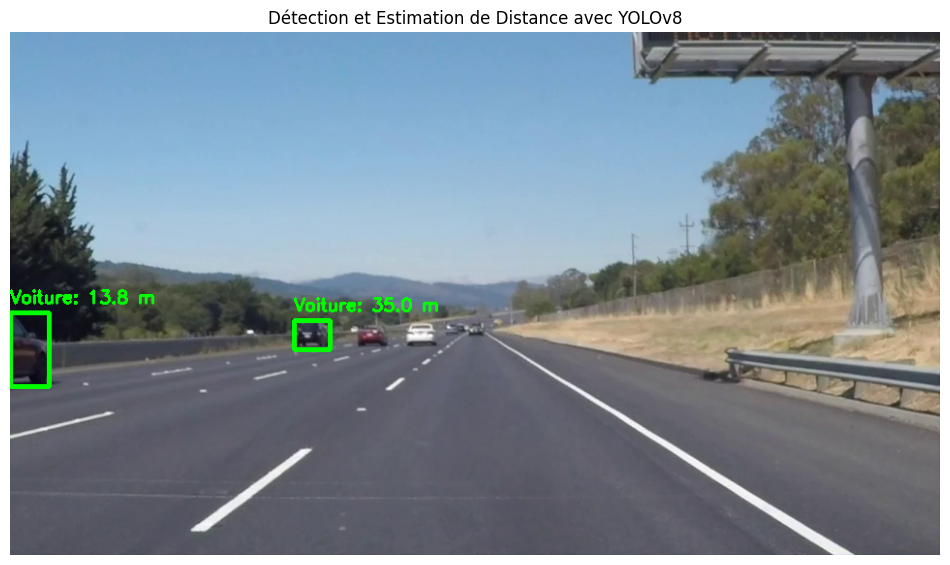

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import urllib.request

print("Chargement de l'IA YOLOv8...")
model = YOLO('yolov8n.pt')

focal_length = 700.0
REAL_CAR_HEIGHT = 1.5

url = "https://github.com/udacity/CarND-LaneLines-P1/raw/master/test_videos/solidWhiteRight.mp4"
urllib.request.urlretrieve(url, "test_video.mp4")

cap = cv2.VideoCapture("test_video.mp4")
ret, frame = cap.read()
cap.release()

results = model(frame, classes=[2, 5, 7], conf=0.4)[0]

img_result = frame.copy()

for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    pixel_height = y2 - y1

    distance_z = (focal_length * REAL_CAR_HEIGHT) / pixel_height

    cv2.rectangle(img_result, (x1, y1), (x2, y2), (0, 255, 0), 3)

    label = f"Voiture: {distance_z:.1f} m"
    cv2.putText(img_result, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

img_rgb = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(img_rgb)
plt.title("Détection et Estimation de Distance avec YOLOv8")
plt.axis('off')
plt.show()

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cx = 480.0

map_cars_x = []
map_cars_z = []

print("Demarrage du SLAM")

vo = VisualOdometry(K, "poses_00.txt")

frame_id = 0
max_frames = 150

while cap.isOpened() and frame_id < max_frames:
  ret, frame = cap.read()
  if not ret:
    break

  gray_frame= cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
  vo.new_frame = gray_frame
  vo.process_frame(frame_id)
  vo.last_frame = gray_frame

  if frame_id % 10 == 0:
    results = model(frame, classes = [2,5,7], conf = 0.5,verbose = False)[0]

    for box in results.boxes:
      x1, y1, x2, y2 = map(int, box.xyxy[0])
      pixel_height = y2 - y1
      u = (x1 + x2) / 2.0

      z_local = (focal_length * REAL_CAR_HEIGHT) / pixel_height
      x_local = ((u - cx) * z_local) / focal_length

      pos_local = np.array([[x_local], [0], [z_local]])

      pos_global = vo.cur_t + vo.cur_R.dot(pos_local)

            # On sauvegarde pour l'affichage
      map_cars_x.append(pos_global[0, 0])
      map_cars_z.append(pos_global[2, 0])

    frame_id += 1

cap.release()
print("Traitement terminé ! Génération de la carte sémantique...")

# --- 3. AFFICHAGE DE LA CARTE ---
plt.figure(figsize=(10, 8))

# Affichage de notre trajectoire
plt.plot(vo.traj_x, vo.traj_z, color='blue', linewidth=2, label="Notre Trajectoire")
plt.scatter(vo.traj_x[0], vo.traj_z[0], color='green', marker='o', s=100, label="Départ", zorder=5)

# Affichage des voitures détectées sur la carte
plt.scatter(map_cars_x, map_cars_z, color='orange', marker='s', s=50, label="Voitures détectées (YOLO)", alpha=0.7)

plt.title("Carte Sémantique (Object-Centric SLAM)")
plt.xlabel("Axe X (Latéral en mètres)")
plt.ylabel("Axe Z (Profondeur en mètres)")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

Demarrage du SLAM


NameError: name 'K' is not defined